In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index --Extension"


### Parameters

In [2]:
data_name = "us_100000000"
k=25
point_query = []
range_query = []
knn_query = []
point_query_time = []
range_query_time = []
knn_query_time = []
build_time = []
baselines = ['bmtree', 'bmtree_impr']
display_baselines = ['BM-tree', 'BM-tree-Impr']
data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]
special_baselines = ['bmtree', 'bmtree_impr']

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"


synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':
                   ['_bits_32_depth_10_sample_80000', 
                    '_bits_32_depth_10_sample_20000',
                    '_bits_32_depth_8_sample_40000',
                    '_bits_32_depth_12_sample_40000',
                    '_bits_32_depth_8_sample_20000',
                    '_bits_32_depth_12_sample_40000'],                   
                   'bmtree_impr':['_bits_32_depth_10_sample_80000', 
                    '_bits_32_depth_10_sample_20000',
                    '_bits_32_depth_8_sample_40000',
                    '_bits_32_depth_12_sample_40000',
                    '_bits_32_depth_8_sample_20000',
                    '_bits_32_depth_12_sample_40000']}

for i, data_name in enumerate(data_names):    

    point_query_sampled = []
    range_query_sampled = []
    knn_query_sampled = []
    build_time_sampled = []
    point_query_sampled_time = []
    range_query_sampled_time = []
    knn_query_sampled_time = []
    
    for baseline in baselines:
        suffix = baseline_suffix[baseline][i]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            knn_name = synthetic_knn_name
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''

        # default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        range_name=real_range_name_pattern.format(data_name=data_name)
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline,disk_type="HDD"), build_result_name)
        tree_property = parse_rtree_properties(res)

        print(res)
        
        build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9 + tree_property.ElapsedBuildTime / 1e9)
        # build_time_sampled.append(tree_property.ElapsedTime / 1e9)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )
        
        res = os.path.join(point_result_path.format(name=baseline,disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        # print(res)
        point_query_sampled_time.append(tree_property.QueryMean / 1e3)
        point_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=default_range_name,
            suffix=suffix
        )
        # print(range_result_name)

        res = os.path.join(range_result_path.format(name=baseline,disk_type="HDD"), range_result_name)
        # if baseline == 'bmtree':
        # print(res)
        
        tree_property = parse_rtree_properties(res)
        range_query_sampled_time.append(tree_property.QueryMean / 1e3)
        range_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)
        

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline,disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_sampled_time.append(tree_property.QueryMean / 1e3)
        knn_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)
        

    point_query.append(point_query_sampled)
    range_query.append(range_query_sampled)
    knn_query.append(knn_query_sampled)
    point_query_time.append(point_query_sampled_time)
    range_query_time.append(range_query_sampled_time)
    knn_query_time.append(knn_query_sampled_time)
    build_time.append(build_time_sampled)
    
print(point_query)
print(range_query)
print(knn_query)
print(build_time)

../result/libspatialindex/HDD/4K/bmtree/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_80000.txt
../result/libspatialindex/HDD/4K/bmtree_impr/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_80000.txt
../result/libspatialindex/HDD/4K/bmtree/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_20000.txt
../result/libspatialindex/HDD/4K/bmtree_impr/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_20000.txt
../result/libspatialindex/HDD/4K/bmtree/build/australia_100000000_australia_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_8_sample_40000.txt
../result/libspatialindex/HDD/4K/bmtree_impr/build/australia_100000000_australia_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_8_sample_40000.txt
../result/libspatialindex/HDD/4K/bmtree/build/data_100000000_2_uniform_1_range_1000_2_uniform_1_0.001

In [3]:
# # import matplotlib.pyplot as plt
# # import numpy as np
# # colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']

# all_data = [build_time, range_query, point_query, knn_query]
# query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
# # bottoms = [1e3, 1*1e1, 1e1, 1e1]
# # tops = [2*1e4, 1*1e3, 1*1e2, 1*1e2]

# bottoms = [0, 1, 0, 0]
# tops = [25000, 1000, 25, 30]

# # display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

# group_width = 0.8  
# individual_bar_width = group_width / 2  
# offset = individual_bar_width / 2  

# fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

# for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
#     x = np.arange(len(display_data_names)) 

    
#     bmtree = [row[0] for row in data] 
#     bmtree_impr = [row[1] for row in data] 

#     # print(x - offset, hdd_values)
    
#     ax.bar(x - offset, bmtree, individual_bar_width, label=display_baselines[0], color=colors[0], alpha=1.0, hatch='//', align='center') 
#     ax.bar(x + offset, bmtree_impr, individual_bar_width, label=display_baselines[1], color=colors[3], alpha=1.0, hatch='-', align='center') 

#     ax.set_title(f'{query_type}', fontsize=16)

#     ax.set_xticks(x)  # x 是柱子中心的位置
#     ax.set_xticklabels(['US', 'INDIA', 'AUS', 'UNI', 'NORM', 'SKEW'], fontsize=13)
    
#     # if i > 1:
#     #     ax.set_xticks(x)  
#     #     ax.set_xticklabels(display_data_names, rotation=0, ha='right') 
#     # else:
#     #     ax.set_xticks([])  
#     # ax.set_xticks(x)  
#     # ax.set_xticklabels(display_baselines, rotation=45, ha='right') 

#     # ax.set_title(query_types[i])

#     if i == 0:
#         ax.set_ylabel('Build Time (s)', fontsize=16) 
#     else:
#         ax.set_ylabel('Total I/O', fontsize=16) 

#     ax.set_ylim(bottom=bottoms[i])
#     ax.set_ylim(top=tops[i])

#     ax.tick_params(axis='y', labelsize=12)

#     if i == 1:
#         ax.set_yscale('log')
#     ax.grid(True, axis='y', linestyle='--', alpha=1.0)

# axes[0, 0].legend(loc='upper left', fontsize=13, ncol=2)  

# output_file_paths = [folder + "/exp_sigmod/bmtree_improved.pdf", "../figs/exp_sigmod/bmtree_improved.png"]

# plt.tight_layout()

# if output_file_paths:
#     for output_file_path in output_file_paths:
#         if output_file_path.endswith(".pdf"):
#             plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
#         if output_file_path.endswith(".png"):
#             plt.savefig(output_file_path, format='png', bbox_inches='tight')


# plt.show()

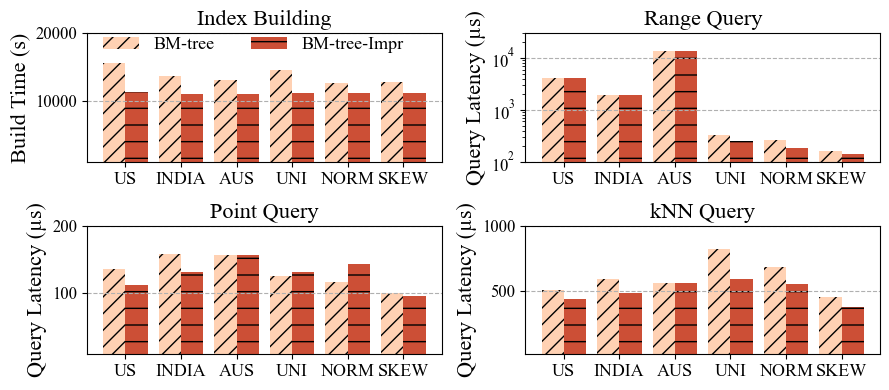

[[136.46047451, 112.31409588], [158.96685897999998, 131.060929565], [156.343508785, 156.343817465], [126.34679695, 132.287232555], [117.089607275, 142.92974651999998], [100.409849555, 95.91247077499999]]
[[4155.363062, 4155.363352], [1948.486086, 1948.48696], [13671.837911, 13758.155001000001], [332.76193199999994, 249.264573], [263.433365, 186.893579], [159.371631, 143.44544699999997]]
[[504.55838400000005, 439.117755], [589.4785720000001, 485.803908], [559.851162, 559.851812], [819.616851, 587.12771], [686.2245810000001, 552.735669], [453.819153, 375.542732]]


In [4]:
# import matplotlib.pyplot as plt
# import numpy as np
# colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']
# ====================================================
all_data = [build_time, range_query_time, point_query_time, knn_query_time]
query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
bottoms = [1e3, 1*1e2, 1e1, 1e1]
tops = [2*1e4, 3*1e4, 2*1e2, 1*1e3]

# display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

group_width = 0.8  
individual_bar_width = group_width / 2  
offset = individual_bar_width / 2  

fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

# ====================================================
# all_data = [build_time, range_query_time]
# query_types = ['Index Building', 'Range Query']
# bottoms = [1e3, 1*1e2]
# tops = [3*1e4, 3*1e4]

# # display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

# group_width = 0.8  
# individual_bar_width = group_width / 2  
# offset = individual_bar_width / 2  

# fig, axes = plt.subplots(1, 2, figsize=(9, 2), sharey=False)
# ====================================================

for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
    x = np.arange(len(display_data_names)) 

    
    bmtree = [row[0] for row in data] 
    bmtree_impr = [row[1] for row in data] 

    # print(x - offset, hdd_values)
    
    # ax.bar(x - offset, bmtree, individual_bar_width, label=display_baselines[0], color=colors[4], alpha=1.0, hatch='//', align='center') 
    # ax.bar(x + offset, bmtree_impr, individual_bar_width, label=display_baselines[1], color=colors[7], alpha=1.0, hatch='-', align='center') 
    ax.bar(x - offset, bmtree, individual_bar_width, label=display_baselines[0], color=colors[4], alpha=1.0, hatch='//', align='center') 
    ax.bar(x + offset, bmtree_impr, individual_bar_width, label=display_baselines[1], color=colors[7], alpha=1.0, hatch='-', align='center') 

    ax.set_title(f'{query_type}', fontsize=16)

    ax.set_xticks(x)  # x 是柱子中心的位置
    ax.set_xticklabels(['US', 'INDIA', 'AUS', 'UNI', 'NORM', 'SKEW'], fontsize=13)
    
    # if i > 1:
    #     ax.set_xticks(x)  
    #     ax.set_xticklabels(display_data_names, rotation=0, ha='right') 
    # else:
    #     ax.set_xticks([])  
    # ax.set_xticks(x)  
    # ax.set_xticklabels(display_baselines, rotation=45, ha='right') 

    # ax.set_title(query_types[i])

    if i == 0:
        ax.set_ylabel('Build Time (s)', fontsize=16) 
    else:
        ax.set_ylabel('Query Latency (µs)', fontsize=16) 

    ax.set_ylim(bottom=bottoms[i])
    ax.set_ylim(top=tops[i])

    ax.tick_params(axis='y', labelsize=12)

    if i == 1:
        ax.set_yscale('log')
    ax.grid(True, axis='y', linestyle='--', alpha=1.0)

    if i == 0:
        ax.legend(loc='upper left', fontsize=13, frameon=False, ncol=2, bbox_to_anchor=(0, 1.1))  

output_file_paths = [folder + "/exp_sigmod/bmtree_improved_time.pdf", "../figs/exp_sigmod/bmtree_improved_time.png"]

plt.tight_layout()

if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')


plt.show()


print(point_query_time)
print(range_query_time)
print(knn_query_time)

In [5]:
data_name = "us_100000000"
k=25
point_query = []
range_query = []
knn_query = []
point_query_time = []
range_query_time = []
knn_query_time = []
build_time = []
baselines = ['rlrtree', 'rlrtree_impr']
display_baselines = ['RLR-tree', 'RLR-tree-Impr']
data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]
special_baselines = ['rlrtree', 'rlrtree_impr']

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"


synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"


baseline_suffix = {'rlrtree':
                   ['_rlrtree_epoch_6_sample_80000', 
                    '_rlrtree_epoch_8_sample_40000',
                    '_rlrtree_epoch_8_sample_10000',
                    '_rlrtree_epoch_10_sample_80000',
                    '_rlrtree_epoch_8_sample_40000',
                    '_rlrtree_epoch_6_sample_10000'],                   
                   'rlrtree_impr':['_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0', 
                    '_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0',
                    '_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0',
                    '_rlrtree_epoch_2_sample_20000_gamma_0.8_learning_rate_0.01_rl_method_0',
                    '_rlrtree_epoch_2_sample_20000_gamma_0.8_learning_rate_0.01_rl_method_0',
                    '_rlrtree_epoch_1_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0']}

for i, data_name in enumerate(data_names):    

    point_query_sampled = []
    range_query_sampled = []
    knn_query_sampled = []
    build_time_sampled = []
    point_query_sampled_time = []
    range_query_sampled_time = []
    knn_query_sampled_time = []
    
    for baseline in baselines:
        suffix = baseline_suffix[baseline][i]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            knn_name = synthetic_knn_name
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''

        # default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        range_name=real_range_name_pattern.format(data_name=data_name)
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline,disk_type="HDD"), build_result_name)
        tree_property = parse_rtree_properties(res)

        print(res)
        
        build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9 + tree_property.ElapsedBuildTime / 1e9)
        # build_time_sampled.append(tree_property.ElapsedTime / 1e9)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        
        res = os.path.join(point_result_path.format(name=baseline,disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        # print(res)
        point_query_sampled_time.append(tree_property.QueryMean / 1e3)
        point_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)

        


        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=default_range_name,
            suffix=suffix
        )
        # print(range_result_name)

        res = os.path.join(range_result_path.format(name=baseline,disk_type="HDD"), range_result_name)
        # if baseline == 'bmtree':
        # print(res)
        
        tree_property = parse_rtree_properties(res)
        range_query_sampled_time.append(tree_property.QueryMean / 1e3)
        range_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)
        

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline,disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_sampled_time.append(tree_property.QueryMean / 1e3)
        knn_query_sampled.append(tree_property.LeafIo / tree_property.QueryNum + tree_property.IndexIo / tree_property.QueryNum)
        

    point_query.append(point_query_sampled)
    range_query.append(range_query_sampled)
    knn_query.append(knn_query_sampled)
    point_query_time.append(point_query_sampled_time)
    range_query_time.append(range_query_sampled_time)
    knn_query_time.append(knn_query_sampled_time)
    build_time.append(build_time_sampled)
    
print(point_query)
print(range_query)
print(knn_query)
print(build_time)

../result/libspatialindex/HDD/4K/rlrtree/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_6_sample_80000.txt
../result/libspatialindex/HDD/4K/rlrtree_impr/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0.txt
../result/libspatialindex/HDD/4K/rlrtree/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_8_sample_40000.txt
../result/libspatialindex/HDD/4K/rlrtree_impr/build/india_100000000_india_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0.txt
../result/libspatialindex/HDD/4K/rlrtree/build/australia_100000000_australia_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_8_sample_10000.txt
../result/libspatialindex/HDD/4K/rlrtree_impr/build/australia_100000000_australia_100000000_range_1000_2_uniform_1_0.001x0.001_rlrtree_epoch_2_sample_10000_gamma_0.8_learning_ra

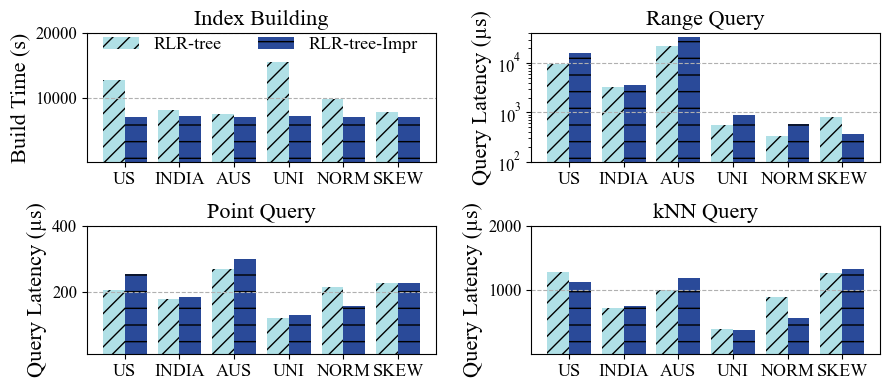

In [6]:
# import matplotlib.pyplot as plt
# import numpy as np
# colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']

all_data = [build_time, range_query_time, point_query_time, knn_query_time]
query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
bottoms = [1, 1*1e2, 1e1, 1e1]
tops = [2*1e4, 4*1e4, 4*1e2, 2*1e3]

# display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

group_width = 0.8  
individual_bar_width = group_width / 2  
offset = individual_bar_width / 2  

fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

# ===================================================================

# all_data = [build_time, range_query_time]
# query_types = ['Index Building', 'Range Query']
# bottoms = [1, 1*1e2]
# tops = [2*1e4, 4*1e4]

# # display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

# group_width = 0.8  
# individual_bar_width = group_width / 2  
# offset = individual_bar_width / 2  

# fig, axes = plt.subplots(1, 2, figsize=(9, 2), sharey=False)

# ===================================================================


for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
    x = np.arange(len(display_data_names)) 

    
    bmtree = [row[0] for row in data] 
    bmtree_impr = [row[1] for row in data] 

    # print(x - offset, hdd_values)
    
    ax.bar(x - offset, bmtree, individual_bar_width, label=display_baselines[0], color=colors[0], alpha=1.0, hatch='//', align='center') 
    ax.bar(x + offset, bmtree_impr, individual_bar_width, label=display_baselines[1], color=colors[3], alpha=1.0, hatch='-', align='center') 

    ax.set_title(f'{query_type}', fontsize=16)

    ax.set_xticks(x)  # x 是柱子中心的位置
    ax.set_xticklabels(['US', 'INDIA', 'AUS', 'UNI', 'NORM', 'SKEW'], fontsize=13)
    
    # if i > 1:
    #     ax.set_xticks(x)  
    #     ax.set_xticklabels(display_data_names, rotation=0, ha='right') 
    # else:
    #     ax.set_xticks([])  
    # ax.set_xticks(x)  
    # ax.set_xticklabels(display_baselines, rotation=45, ha='right') 

    # ax.set_title(query_types[i])

    if i == 0:
        ax.set_ylabel('Build Time (s)', fontsize=16) 
    else:
        ax.set_ylabel('Query Latency (µs)', fontsize=16) 

    ax.set_ylim(bottom=bottoms[i])
    ax.set_ylim(top=tops[i])

    ax.tick_params(axis='y', labelsize=12)

    if i == 1:
        ax.set_yscale('log')
    ax.grid(True, axis='y', linestyle='--', alpha=1.0)

    if i == 0:
        ax.legend(loc='upper left', fontsize=13, ncol=2, frameon=False, bbox_to_anchor=(0, 1.1))  

output_file_paths = [folder + "/exp_sigmod/rlrtree_improved_time.pdf", "../figs/exp_sigmod/rlrtree_improved_time.png"]

plt.tight_layout()

if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')


plt.show()